In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




# find candidate genes which may repress ptf1a activation in precursor cells

In [13]:
# import putative TFs which may bind to tal1 promoter, predicted by animalTFDB4 according to DNA motif analysis
motifs <- read.csv("TFBSResult-ptf1a.tsv",sep = "\t", header = T)
motifs <- motifs[motifs$Qvalue < 0.2, ]

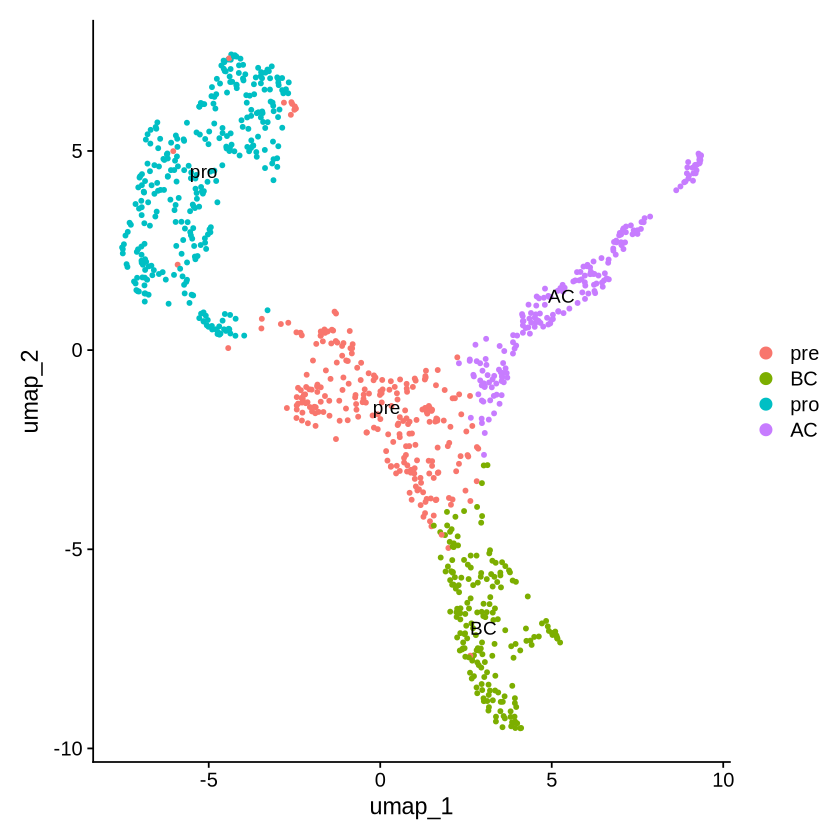

In [14]:
# import scRNAseq result
acbc_rnaseq <- readRDS(file = "~/NGS/scRNA/AA/acbc_rna.rds")
DimPlot(acbc_rnaseq, reduction = "umap", label = TRUE)


## determine expression of these motif genes

In [15]:
# match the motif name with gene name
## extract and process motif name, rename pattern "nkx6-2" to "nkx6.2"
list.motif <- unique(tolower(motifs$TF))
list.motif.process <- gsub('-', '.', list.motif)

## extract gene name from scRNAseq result
list.rna <- rownames(acbc_rnaseq)

## create a function to find fuzzy matches
find_fuzzy_matches <- function(list.rna, list.motif.process) {
  list.rna.lower <- tolower(list.rna)
  
  matched_genes <- c()
  
  for (motif_gene in list.motif.process) {
    matches <- grep(paste0("^", motif_gene, "[a-d]?$"), list.rna.lower, value = FALSE)
    if (length(matches) > 0) {
      matched_genes <- c(matched_genes, list.rna[matches])
    }
  }
  
  return(unique(matched_genes))
}

## find fuzzy matches using the function
matched_genes <- find_fuzzy_matches(list.rna, list.motif.process)
length(matched_genes)

[1] 356

## find unmismatched processed motifs

In [16]:
#find unmismatch
find_unmatched_motifs <- function(list.rna, list.motif.process) {
 list.rna.lower <- tolower(list.rna)
  #list.motif.process.lower <- tolower(list.motif.process)
  
  unmatched_motifs <- c()
  
  for (motif_gene in list.motif.process) {
    pattern <- paste0("^", tolower(motif_gene), "[a-d]?$")
    matches <- grep(pattern, list.rna.lower)
    
    if (length(matches) == 0) {
      unmatched_motifs <- c(unmatched_motifs, motif_gene)
    }
  }
  
  return(unmatched_motifs)
}

unmatched_motifs <- find_unmatched_motifs(list.rna, list.motif.process)
length(unmatched_motifs)
sort(unmatched_motifs)

[1] 269

[1] "ahr"     "anhx"    "arid5a"  "arntl"   "arx"     "bcl6"    "cdx2"   
  [8] "cdx4"    "cphx1"   "creb3"   "ctcfl"   "dux4"    "duxa"    "duxbl1" 
 [15] "e2f2"    "erg"     "esx1"    "ets1"    "foxa1"   "foxa2"   "foxc1"  
 [22] "foxc2"   "foxd2"   "foxe1"   "foxf1"   "foxf2"   "foxl1"   "foxl2"  
 [29] "foxp3"   "foxq1"   "foxr2"   "gcm1"    "gcm2"    "gli4"    "glis2"  
 [36] "gm5294"  "gsc"     "gsc2"    "hes1"    "hes2"    "hes7"    "hic1"   
 [43] "hkr1"    "hnf1a"   "hnf1b"   "hoxa1"   "hoxa10"  "hoxa2"   "hoxa3"  
 [50] "hoxa4"   "hoxa5"   "hoxa6"   "hoxa7"   "hoxa9"   "hoxb13"  "hoxb3"  
 [57] "hoxb4"   "hoxb5"   "hoxb6"   "hoxb7"   "hoxb8"   "hoxc12"  "hoxc13" 
 [64] "hoxc4"   "hoxc8"   "hoxd10"  "hoxd11"  "hoxd13"  "hoxd3"   "hoxd8"  
 [71] "hoxd9"   "hsfy1"   "hsfy2"   "ikzf1"   "irf3"    "klf10"   "klf14"  
 [78] "klf15"   "klf16"   "klf3"    "klf5"    "lhx8"    "mlxipl"  "mzf1"   
 [85] "nkx2.1"  "nkx2.3"  "nkx2.4"  "nkx2.5"  "nkx2.6"  "nkx2.8"  "nkx2.9" 
 [92] "nkx6.2"  "nr1i3"   "obox3"   "osr2"    "ovol1"   "pax3"    "pax4"   
 [99] "pgr"     "pitx1"   "pknox1"  "pou1f1"  "pou2f3"  "pou3f2"  "pou3f4" 
[106] "pou4f3"  "pou5f1"  "pou5f1b" "pparg"   "prdm6"   "prrx1"   "prrx2"  
[113] "rarb"    "rbak"    "rbpjl"   "rfx4"    "rfx6"    "rhoxf2"  "snai3"  
[120] "sox15"   "sox17"   "sox30"   "spi1"    "sry"     "t"       "tbx20"  
[127] "tcfl5"   "tgif2"   "tlx2"    "trp53"   "zbtb6"   "zfp1"    "zfp105" 
[134] "zfp182"  "zfp260"  "zfp281"  "zfp287"  "zfp3"    "zfp316"  "zfp319" 
[141] "zfp329"  "zfp367"  "zfp39"   "zfp41"   "zfp42"   "zfp422"  "zfp445" 
[148] "zfp46"   "zfp513"  "zfp526"  "zfp536"  "zfp574"  "zfp579"  "zfp583" 
[155] "zfp652"  "zfp69b"  "zfp74"   "zfp771"  "zfp775"  "zfp784"  "zfp786" 
[162] "zfp82"   "zfp90"   "zkscan1" "zkscan2" "znf101"  "znf12"   "znf124" 
[169] "znf132"  "znf135"  "znf174"  "znf180"  "znf182"  "znf197"  "znf2"   
[176] "znf22"   "znf223"  "znf232"  "znf235"  "znf24"   "znf248"  "znf25"  
[183] "znf250"  "znf257"  "znf263"  "znf264"  "znf274"  "znf282"  "znf283" 
[190] "znf287"  "znf30"   "znf302"  "znf311"  "znf317"  "znf320"  "znf324b"
[197] "znf329"  "znf331"  "znf334"  "znf33b"  "znf35"   "znf350"  "znf354a"
[204] "znf382"  "znf383"  "znf384"  "znf394"  "znf41"   "znf415"  "znf417" 
[211] "znf418"  "znf436"  "znf439"  "znf442"  "znf443"  "znf444"  "znf445" 
[218] "znf449"  "znf460"  "znf467"  "znf484"  "znf487"  "znf492"  "znf496" 
[225] "znf501"  "znf502"  "znf506"  "znf519"  "znf525"  "znf528"  "znf548" 
[232] "znf555"  "znf558"  "znf563"  "znf564"  "znf567"  "znf570"  "znf580" 
[239] "znf582"  "znf585a" "znf586"  "znf595"  "znf610"  "znf613"  "znf627" 
[246] "znf655"  "znf667"  "znf674"  "znf682"  "znf701"  "znf708"  "znf774" 
[253] "znf785"  "znf787"  "znf79"   "znf799"  "znf808"  "znf823"  "znf85"  
[260] "znf879"  "znf880"  "znf891"  "znf90"   "znf93"   "zscan2"  "zscan22"
[267] "zscan23" "zscan31" "zscan9"

## mannually add genes to macthed gene list if needed

In [17]:
suppli.genes <- c("her2", "her1",  "her4.1", "hes2.1", "hes2.2", "her4.2", "her12", "her15.1", "her9", "her6" )
matched_genes <- unique(c(matched_genes, suppli.genes))
length(matched_genes)

[1] 366

# calculate average expression of matched genes

In [18]:
avg_exp <- AverageExpression(acbc_rnaseq, features = matched_genes)$RNA 
avg_exp_df <- as.data.frame(avg_exp)
avg_exp_df$Gene <- rownames(avg_exp_df)
head(avg_exp_df)  

Warning message:
"The following 1 features were not found in the RNA assay: her1"


,pre,BC,pro,AC,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
pbx3a,0.01517834,0.01191266,0.005609085,0.007216465,pbx3a
pbx3b,0.12204465,0.63389683,0.176067054,0.452273972,pbx3b
zbtb20,0.25713332,1.13625910,0.378783985,0.537090082,zbtb20
foxj3,0.09784848,0.20921693,0.189308328,0.162281258,foxj3
vezf1b,0.08750921,0.08086357,0.130863461,0.057312626,vezf1b
vezf1a,0.44789167,0.25375895,0.297232790,0.267967185,vezf1a


# select genes which positively express in pre

In [19]:
pre.positive <- avg_exp_df[avg_exp_df$pre > 0.15, ]
dim(pre.positive)
head(pre.positive)

[1] 98  5

,pre,BC,pro,AC,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
zbtb20,0.2571333,1.1362591,0.3787840,0.5370901,zbtb20
vezf1a,0.4478917,0.2537589,0.2972328,0.2679672,vezf1a
nfyc,1.0961178,1.0178259,1.5949400,1.1823375,nfyc
nfya,0.8811235,0.8176054,1.2769627,1.3066055,nfya
nfyba,3.5323632,3.1945916,3.0349554,4.2266898,nfyba
nfybb,0.7580236,0.2188053,0.9534060,0.6042888,nfybb


# find out genes which express higher in BC than in AC

In [20]:
gene.pre <- pre.positive$Gene
gene.pre <- as.character(gene.pre)
BC.markers <- FindMarkers(acbc_rnaseq, ident.1 = "BC", ident.2 = "AC", features = gene.pre, only.pos = TRUE)


In [21]:
# select BC significantly higher genes
BC.markers <- BC.markers[BC.markers$p_val < 0.05, ]
BC.markers.sig <- BC.markers[BC.markers$avg_log2FC > 1, ]
dim(BC.markers.sig)



[1] 16  5

# draw the heatmap of BC-specific genes, replication of Figure 4D.

Centering and scaling data matrix



Warning message in DoHeatmap(acbc_rnaseq, features = c(rownames(BC.markers.sig), :
"The following features were omitted as they were not found in the scale.data slot for the RNA assay: 5"


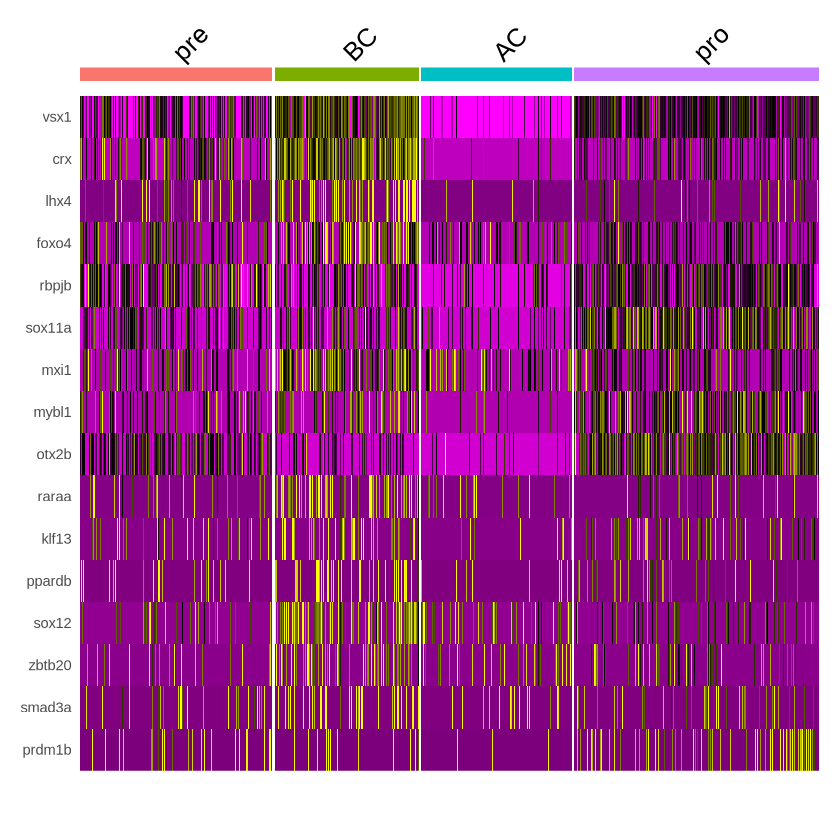

In [22]:
# draw the heatmap of AC and BC markers
acbc_rnaseq <- ScaleData(acbc_rnaseq, features = gene.pre)
acbc_rnaseq@active.ident <- factor(
  acbc_rnaseq@active.ident,
  levels = c("pre", "BC", "AC", "pro") 
)
DoHeatmap(acbc_rnaseq, features = c(rownames(BC.markers.sig), lines.width = 5)) + NoLegend()


## check average expression in progenitor cells

In [23]:
# check average expression in pro
avg_exp_df[rownames(BC.markers.sig), ]

,pre,BC,pro,AC,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
vsx1,12.7787483,51.8496522,21.6916157,1.03326664,vsx1
crx,3.4587637,9.6178070,1.8380234,0.25636554,crx
lhx4,0.4911405,1.3285866,0.1775580,0.05695995,lhx4
foxo4,0.9076917,3.6497735,0.7400806,0.91687454,foxo4
rbpjb,3.6067955,2.4281501,2.7637743,0.89174438,rbpjb
sox11a,1.6588287,2.6063570,5.2483816,0.74146547,sox11a
mxi1,0.9705684,2.4130292,0.8785126,1.04606320,mxi1
mybl1,0.8056821,1.0564427,1.6170414,0.22114772,mybl1
otx2b,2.5677706,1.1761468,5.7083613,0.40610385,otx2b


# enviroment

In [24]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/wangmei/anaconda3/envs/seurat5/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_3.5.1      dplyr_1.1.4        Seurat_5.1.0       SeuratObject_5.0.2
[5] sp_2.1-4          

loaded via a namespace (and not attached):
  [1] deldir_2.0-4           pbapply_1.7-2          gridExtra_2.3         
  [4] rlang_1.1.4            magrittr_2.0.3         RcppAnnoy_0.0.22      
  [7] spatstat.geom_3.2-9    matrixStats_1.4.1      ggridges_0.5.6        
 [10] compiler_4.3.3         png_0.1-8              vctrs_0.6.5           
 [13] reshape2_1.4.4         stringr_1.5.1          pkgconfig_2.0.3       
 [16] crayon_1.5.3           fastmap_1.2.0    